# Carry-Sim Profile (k=1…16) & Accuracy vs. Depth — Standalone
Self-contained notebook. Clones the repo, installs deps, downloads the
checkpoint, builds the dataset, creates all four precision variants
(FP32, INT8, INT4-calibrated, INT4-naive), then runs:

1. **Cosine similarity profile** — `z_H` carry-state similarity between
   consecutive steps k=1…16 for all four precisions (single figure + table).
2. **Accuracy vs. depth** — cell accuracy at H_cycles ∈ {1,2,4,8,16}
   for all four precisions.

**Runtime:** ~30–45 min on a Colab T4/A100 (depth sweep dominates).


## 0 · Environment setup

In [1]:
# Local environment — repo already cloned; download checkpoint if missing
import os, subprocess

ROOT_DIR = "/mnt/c/Users/Vergio/Research/Learning"
REPO_DIR = f"{ROOT_DIR}/EdgeTRM"
TRM_ROOT = f"{REPO_DIR}/TinyRecursiveModels"

assert os.path.isdir(REPO_DIR), f"Repo not found: {REPO_DIR}"
print(f"Repo:  {REPO_DIR}")
print(f"TRM:   {TRM_ROOT}")

# ── Checkpoint (git-lfs clone from HuggingFace, ~4 GB) ───────────────────
CKPT_LOCAL = f"{REPO_DIR}/trm_arc_prize_verification"

if not os.path.exists(CKPT_LOCAL):
    print("Checkpoint not found — cloning from HuggingFace (~4 GB)…")
    subprocess.run(["git", "lfs", "install"], check=True)
    subprocess.run([
        "git", "clone",
        "https://huggingface.co/arcprize/trm_arc_prize_verification",
        CKPT_LOCAL,
    ], check=True)
    print("Clone complete.")
else:
    print(f"Checkpoint present: {CKPT_LOCAL}")


Repo:  /mnt/c/Users/Vergio/Research/Learning/EdgeTRM
TRM:   /mnt/c/Users/Vergio/Research/Learning/EdgeTRM/TinyRecursiveModels
Checkpoint present: /mnt/c/Users/Vergio/Research/Learning/EdgeTRM/trm_arc_prize_verification


In [2]:
import os
os.environ.setdefault("BNB_CUDA_VERSION", "130")  # no CUDA 13.2 binary; 13.0 works
import sys, os, subprocess
from pathlib import Path

ROOT_DIR = "/mnt/c/Users/Vergio/Research/Learning"
TRM_ROOT = f"{ROOT_DIR}/EdgeTRM/TinyRecursiveModels"

if str(TRM_ROOT) not in sys.path:
    sys.path.insert(0, str(TRM_ROOT))

os.chdir(TRM_ROOT)
print("CWD:", os.getcwd())

# Install packages missing from the venv
for pkg, import_name in [("matplotlib", "matplotlib"), ("pyyaml", "yaml"),
                          ("bitsandbytes", "bitsandbytes")]:
    try:
        __import__(import_name)
        print(f"  {pkg}: OK")
    except ImportError:
        print(f"  Installing {pkg}…")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(f"  {pkg}: installed")

print("Dependencies OK.")


CWD: /mnt/c/Users/Vergio/Research/Learning/EdgeTRM/TinyRecursiveModels
  matplotlib: OK
  pyyaml: OK


This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=



  bitsandbytes: OK
Dependencies OK.


## 1 · Imports & globals

In [3]:
import sys, os, time, copy, json, math, warnings, io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

def get_inner(m):
    m2 = m.module if hasattr(m, 'module') else m
    return m2._orig_mod if hasattr(m2, '_orig_mod') else m2

print(f"Device: {DEVICE}")


Device: cuda


## 2 · Build ARC dataset

In [4]:
import os, json

ROOT_DIR    = "/mnt/c/Users/Vergio/Research/Learning"
SOURCE_DIR  = f"{ROOT_DIR}/EdgeTRM/arc-prize-2025"
WORKING_DIR = f"{SOURCE_DIR}/arc_2025_setup"
os.makedirs(WORKING_DIR, exist_ok=True)

print("=== arc-prize-2025 contents ===")
for it in sorted(os.listdir(SOURCE_DIR))[:20]:
    print(f"  {it}")

json_needed = [
    f"{SOURCE_DIR}/arc-agi_training_challenges.json",
    f"{SOURCE_DIR}/arc-agi_evaluation_challenges.json",
    f"{SOURCE_DIR}/arc-agi_test_challenges.json",
]
missing = [p for p in json_needed if not os.path.exists(p)]
if missing:
    print(f"[ERROR] Missing: {missing}")
else:
    print("\nAll required JSON files present.")

def setup_arc_split(subset_name, has_solutions=True):
    challenge_src  = f"{SOURCE_DIR}/arc-agi_{subset_name}_challenges.json"
    solution_src   = f"{SOURCE_DIR}/arc-agi_{subset_name}_solutions.json"
    challenge_link = f"{WORKING_DIR}/arc_{subset_name}_challenges.json"
    solution_link  = f"{WORKING_DIR}/arc_{subset_name}_solutions.json"
    if os.path.lexists(challenge_link): os.remove(challenge_link)
    if not os.path.exists(challenge_src):
        print(f"  [MISSING] {challenge_src}"); return False
    os.symlink(challenge_src, challenge_link)
    if has_solutions and os.path.exists(solution_src):
        if os.path.lexists(solution_link): os.remove(solution_link)
        os.symlink(solution_src, solution_link)
    else:
        with open(challenge_src) as f:
            ch = json.load(f)
        dummy = {k: [[[0]] for _ in v['test']] for k, v in ch.items()}
        with open(solution_link, 'w') as f:
            json.dump(dummy, f)
    return True

ok_train = setup_arc_split('training',   has_solutions=True)
ok_eval  = setup_arc_split('evaluation', has_solutions=True)
ok_test  = setup_arc_split('test',       has_solutions=False)
print(f"Symlinks: training={ok_train}  evaluation={ok_eval}  test={ok_test}")
print("Files in working dir:", sorted(os.listdir(WORKING_DIR)))


=== arc-prize-2025 contents ===
  arc-agi_evaluation_challenges.json
  arc-agi_evaluation_solutions.json
  arc-agi_test_challenges.json
  arc-agi_training_challenges.json
  arc-agi_training_solutions.json
  arc_2025_setup
  sample_submission.json

All required JSON files present.
Symlinks: training=True  evaluation=True  test=True
Files in working dir: ['arc_evaluation_challenges.json', 'arc_evaluation_solutions.json', 'arc_test_challenges.json', 'arc_test_solutions.json', 'arc_training_challenges.json', 'arc_training_solutions.json']


In [5]:
# import os, glob, subprocess, sys

# ROOT_DIR    = "/mnt/c/Users/Vergio/Research/Learning"
# TRM_ROOT    = f"{ROOT_DIR}/EdgeTRM/TinyRecursiveModels"
# DATA_DIR    = f"{ROOT_DIR}/EdgeTRM/data1/arc2test-aug-128"   # pre-built locally
# WORKING_DIR = f"{ROOT_DIR}/EdgeTRM/arc-prize-2025/arc_2025_setup"
# PREFIX      = f"{WORKING_DIR}/arc"

# os.makedirs(DATA_DIR, exist_ok=True)
# os.chdir(TRM_ROOT)
# print(f"CWD: {os.getcwd()}")
# print(f"DATA_DIR: {DATA_DIR}")

# def needs_build(split_name):
#     return not os.path.exists(f"{DATA_DIR}/{split_name}/all__inputs.npy")

# if needs_build("train") and needs_build("training") and needs_build("evaluation"):
#     print("\nBuilding train split…")
#     subprocess.run([sys.executable, "-m", "dataset.build_arc_dataset",
#         "--input-file-prefix", PREFIX, "--output-dir", DATA_DIR,
#         "--subsets", "training", "evaluation", "--test-set-name", "evaluation"],
#         check=True)
#     for cand in ["training", "evaluation"]:
#         if os.path.exists(f"{DATA_DIR}/{cand}") and not os.path.exists(f"{DATA_DIR}/train"):
#             os.symlink(f"{DATA_DIR}/{cand}", f"{DATA_DIR}/train")
#             print(f"  Symlinked {cand}/ → train/"); break
# else:
#     print("Train split already present — skipping")

# if needs_build("test"):
#     print("\nBuilding test split…")
#     subprocess.run([sys.executable, "-m", "dataset.build_arc_dataset",
#         "--input-file-prefix", PREFIX, "--output-dir", DATA_DIR,
#         "--subsets", "test", "--test-set-name", "test"], check=True)
# else:
#     print("Test split already present — skipping")

# print("\n=== Dataset layout ===")
# for d in sorted(os.listdir(DATA_DIR)):
#     p = f"{DATA_DIR}/{d}"
#     npy = glob.glob(f"{p}/*.npy") if os.path.isdir(p) else []
#     print(f"  {d}/  — {len(npy)} .npy files")


## 3 · Load pretrained model

In [6]:
import sys, os, torch, yaml

ROOT_DIR = "/mnt/c/Users/Vergio/Research/Learning"
TRM_ROOT = f"{ROOT_DIR}/EdgeTRM/TinyRecursiveModels"
if str(TRM_ROOT) not in sys.path:
    sys.path.insert(0, TRM_ROOT)
os.chdir(TRM_ROOT)

from trm import TinyRecursiveReasoningModel_ACTV1

CHECKPOINT = f"{REPO_DIR}/trm_arc_prize_verification/arc_v1_public/step_518071"

CONFIG_YAML = """
arch:
  H_cycles: 3
  H_layers: 0
  L_cycles: 4
  L_layers: 2
  expansion: 4
  forward_dtype: bfloat16
  halt_exploration_prob: 0.1
  halt_max_steps: 16
  hidden_size: 512
  num_heads: 8
  pos_encodings: rope
  puzzle_emb_len: 16
  puzzle_emb_ndim: 512
global_batch_size: 512
"""

def load_arc_model(checkpoint_path, config_text):
    raw  = yaml.safe_load(config_text)
    arch = raw['arch']
    cfg  = {
        "batch_size":              32,
        "seq_len":                 900,
        "num_puzzle_identifiers":  876406,
        "vocab_size":              12,
        "H_cycles":                arch['H_cycles'],
        "L_cycles":                arch['L_cycles'],
        "H_layers":                arch['H_layers'],
        "L_layers":                arch['L_layers'],
        "hidden_size":             arch['hidden_size'],
        "expansion":               arch['expansion'],
        "num_heads":               arch['num_heads'],
        "pos_encodings":           arch['pos_encodings'],
        "halt_max_steps":          arch['halt_max_steps'],
        "halt_exploration_prob":   arch['halt_exploration_prob'],
        "forward_dtype":           arch.get('forward_dtype', 'bfloat16'),
        "mlp_t":                   arch.get('mlp_t', False),
        "puzzle_emb_ndim":         arch.get('puzzle_emb_ndim', 512),
        "puzzle_emb_len":          arch.get('puzzle_emb_len', 16),
        "no_ACT_continue":         arch.get('no_ACT_continue', True),
    }
    mdl = TinyRecursiveReasoningModel_ACTV1(config_dict=cfg)
    sd  = torch.load(checkpoint_path, map_location='cpu')
    if 'model' in sd:
        sd = sd['model']
    prefix = '_orig_mod.model.'
    sd = {(k[len(prefix):] if k.startswith(prefix) else k): v for k, v in sd.items()}
    mdl.load_state_dict(sd)
    mdl.eval()
    print("Model loaded OK")
    return mdl

model = load_arc_model(CHECKPOINT, CONFIG_YAML)
model = model.to(DEVICE)
print(f"Model on: {next(model.parameters()).device}")


Model loaded OK
Model on: cuda:0


## 4 · DataLoader

In [7]:
import os, json, numpy as np, torch
from torch.utils.data import Dataset, DataLoader

ROOT_DIR = "/mnt/c/Users/Vergio/Research/Learning"
DATA_DIR = f"{ROOT_DIR}/EdgeTRM/data1/arc2test-aug-128"

class ARCDataset(Dataset):
    def __init__(self, split_dir):
        split_dir = os.path.realpath(split_dir)
        self.inputs = np.load(f"{split_dir}/all__inputs.npy")
        self.labels = np.load(f"{split_dir}/all__labels.npy")
        puzzle_ids  = np.load(f"{split_dir}/all__puzzle_identifiers.npy")
        puzzle_ptr  = np.load(f"{split_dir}/all__puzzle_indices.npy")
        counts = np.diff(puzzle_ptr).astype(np.int64)
        self.per_sample_pids = np.repeat(puzzle_ids, counts)
        assert len(self.inputs) == len(self.per_sample_pids), \
            f"Shape mismatch: inputs={len(self.inputs)}, pids={len(self.per_sample_pids)}"
        meta = None
        for candidate in [split_dir,
                          os.path.join(split_dir, '..', 'train'),
                          os.path.join(split_dir, '..', 'training'),
                          os.path.join(split_dir, '..', 'evaluation')]:
            meta_path = os.path.join(candidate, 'dataset.json')
            if os.path.exists(meta_path):
                with open(meta_path) as fj:
                    meta = json.load(fj)
                break
        if meta is None:
            raise FileNotFoundError(f"dataset.json not found near {split_dir}")
        self.seq_len = meta["seq_len"]

    def __len__(self):  return len(self.inputs)
    def __getitem__(self, i):
        return (
            torch.tensor(self.inputs[i],         dtype=torch.long),
            torch.tensor(self.labels[i],          dtype=torch.long),
            torch.tensor(self.per_sample_pids[i], dtype=torch.long),
        )

train_split = None
for candidate in ["train", "training", "evaluation"]:
    path = f"{DATA_DIR}/{candidate}"
    if os.path.exists(f"{path}/all__inputs.npy"):
        train_split = path
        print(f"Using split directory: {candidate}/")
        break

if train_split is None:
    print("[ERROR] No train split found in", DATA_DIR)
    print("Subdirs:", os.listdir(DATA_DIR))
    train_ds = train_loader = None
else:
    try:
        train_ds     = ARCDataset(train_split)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
        print(f"Loaded {len(train_ds):,} samples  seq_len={train_ds.seq_len}")
    except Exception as e:
        import traceback; traceback.print_exc()
        train_ds = train_loader = None


Using split directory: train/
Loaded 4,340,789 samples  seq_len=900


## 5 · Evaluation & depth-sweep helpers

In [8]:
from models.recursive_reasoning.trm import (
    TinyRecursiveReasoningModel_ACTV1Carry,
    TinyRecursiveReasoningModel_ACTV1InnerCarry,
)

def _get_max_pid(inner):
    """Return the max valid puzzle identifier for this model."""
    try:
        return get_inner(inner).puzzle_emb.weights.shape[0] - 1
    except Exception:
        return 2**31 - 1

@torch.no_grad()
def evaluate_arc(mdl, loader, device="cuda", n_sup_max=16, max_batches=None):
    inner = get_inner(mdl)
    inner.eval()
    inner = inner.to(device)
    max_pid = _get_max_pid(inner)
    if device == "cpu":
        for attr in ["H_init", "L_init"]:
            buf = getattr(inner.inner, attr, None)
            if buf is not None and buf.dtype == torch.bfloat16:
                setattr(inner.inner, attr, nn.Buffer(buf.float(), persistent=False))
    exact_correct = cell_correct = total_cells = total = 0
    t0 = time.time()
    for idx, (x, y, pids) in enumerate(loader):
        if max_batches is not None and idx >= max_batches:
            break
        x, y, pids = x.to(device), y.to(device), pids.to(device)
        pids = pids.clamp(0, max_pid)
        B, seq_len = x.shape
        batch = {"inputs": x.to(torch.int32), "labels": y.to(torch.int32),
                 "puzzle_identifiers": pids.to(torch.int32)}
        carry = inner.initial_carry(batch)
        ic    = carry.inner_carry
        cast  = lambda t: t.to(device).float() if (device=="cpu" and t.dtype==torch.bfloat16) else t.to(device)
        carry = TinyRecursiveReasoningModel_ACTV1Carry(
            inner_carry=TinyRecursiveReasoningModel_ACTV1InnerCarry(
                z_H=cast(ic.z_H), z_L=cast(ic.z_L)),
            steps=carry.steps.to(device), halted=carry.halted.to(device),
            current_data={k: v.to(device) for k, v in carry.current_data.items()})
        last_out = None
        for _ in range(n_sup_max):
            carry, out = inner(carry, batch)
            last_out = out
            if carry.halted.all(): break
        if last_out is None: continue
        preds = last_out["logits"].argmax(-1).cpu()
        y_cpu = y.cpu()
        exact_correct += (preds == y_cpu).all(dim=-1).sum().item()
        mask = y_cpu != 0
        cell_correct  += (preds[mask] == y_cpu[mask]).sum().item()
        total_cells   += mask.sum().item()
        total         += B
    if total == 0: return 0.0, 0.0, 0.0
    cell_acc = cell_correct / total_cells if total_cells > 0 else 0.0
    return exact_correct / total, cell_acc, (time.time() - t0) / total

def evaluate_at_depth(mdl, loader, h_cycles_override, device="cuda", max_batches=10):
    """Evaluate with exactly h_cycles_override H-steps total.

    One call to inner.inner() runs H_cycles H-steps internally.
    Setting H_cycles=h and n_sup_max=1 gives exactly h H-steps per sample.
    Using n_sup_max=h would give h*h H-steps (k² instead of k).
    """
    inner   = get_inner(mdl)
    orig_h  = inner.config.H_cycles
    orig_ih = inner.inner.config.H_cycles
    try:
        inner.config.H_cycles       = h_cycles_override
        inner.inner.config.H_cycles = h_cycles_override
        exact, cell, _ = evaluate_arc(mdl, loader, device=device,
                                       n_sup_max=1,
                                       max_batches=max_batches)
    finally:
        inner.config.H_cycles       = orig_h
        inner.inner.config.H_cycles = orig_ih
    return exact, cell

print("evaluate_arc / evaluate_at_depth defined  (cell acc excludes label==0).")
if 'model' in dir():
    _inner = get_inner(model)
    max_pid = _get_max_pid(_inner)
    print(f"  puzzle_emb size: {max_pid+1}  (max valid ID = {max_pid})")
    if 'train_loader' in dir() and train_loader is not None:
        sample_pids = next(iter(train_loader))[2]
        print(f"  dataset pid range: [{sample_pids.min().item()}, {sample_pids.max().item()}]")
        if sample_pids.max().item() > max_pid:
            print(f"  *** OUT-OF-RANGE IDs detected — clamp active ***")
        else:
            print(f"  IDs in range — OK")

evaluate_arc / evaluate_at_depth defined  (cell acc excludes label==0).
  puzzle_emb size: 876406  (max valid ID = 876405)
  dataset pid range: [2750, 926982]
  *** OUT-OF-RANGE IDs detected — clamp active ***


## 6 · Quantisation helpers

In [9]:
import io
from models.layers import CastedLinear

def _safe_clone(mdl):
    """Clone a model via save/load — avoids deepcopy failure on non-leaf tensors."""
    buf = io.BytesIO()
    torch.save(mdl, buf)
    buf.seek(0)
    return torch.load(buf, map_location='cpu', weights_only=False)

# ── INT8 via bitsandbytes ─────────────────────────────────────────────────────
def quantize_int8_bnb(mdl):
    import bitsandbytes as bnb
    from bitsandbytes.nn import Linear8bitLt
    m = _safe_clone(get_inner(mdl)).cuda()
    replaced = 0
    for name, module in list(m.named_modules()):
        if not isinstance(module, (nn.Linear, CastedLinear)): continue
        out_f, in_f = module.weight.shape
        has_bias = module.bias is not None
        new = Linear8bitLt(in_f, out_f, bias=has_bias,
                           has_fp16_weights=False, threshold=6.0).cuda()
        new.weight = bnb.nn.Int8Params(module.weight.data.to(torch.float16),
                                       requires_grad=False, has_fp16_weights=False)
        if has_bias:
            new.bias = nn.Parameter(module.bias.data.to(torch.float16))
        parts = name.split(".")
        parent = m
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], new)
        replaced += 1
    print(f"  {replaced} layers → Linear8bitLt (INT8)")
    return m

# ── INT4 naive fake-quant ─────────────────────────────────────────────────────
class FakeQuantINT4(nn.Module):
    def __init__(self, weight, bias=None):
        super().__init__()
        self.weight = nn.Parameter(weight.detach().clone(), requires_grad=False)
        self.bias   = nn.Parameter(bias.detach().clone(),   requires_grad=False) if bias is not None else None
    def _fq(self, x, n=4):
        qmax = 2**(n-1)-1
        s = x.float().abs().max().clamp(1e-8) / qmax
        return (torch.clamp((x.float()/s).round(), -qmax, qmax) * s).to(x.dtype)
    def forward(self, x):
        return F.linear(x, self._fq(self.weight).to(x.dtype),
                        self.bias.to(x.dtype) if self.bias is not None else None)

def quantize_int4_naive(mdl):
    m = _safe_clone(get_inner(mdl))
    replaced = 0
    for name, module in list(m.named_modules()):
        if not isinstance(module, (nn.Linear, CastedLinear)): continue
        parts = name.split(".")
        parent = m
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], FakeQuantINT4(module.weight, module.bias))
        replaced += 1
    print(f"  {replaced} layers → FakeQuantINT4 (naive)")
    return m

# ── INT4 calibrated fake-quant ────────────────────────────────────────────────
class CalibratedFakeQuantINT4(nn.Module):
    def __init__(self, weight, bias=None, n_bits=4):
        super().__init__()
        w = weight.detach().float()
        q_min, q_max = -(2**(n_bits-1)), 2**(n_bits-1)-1
        rmin = w.min(dim=1).values
        rmax = w.max(dim=1).values
        scale = (rmax - rmin).clamp(1e-8) / (q_max - q_min)
        zp    = (q_min - rmin / scale).round().clamp(q_min, q_max).to(torch.int8)
        self.q_min, self.q_max = q_min, q_max
        self.register_buffer("scale", scale)
        self.register_buffer("zp",    zp)
        sc = scale.unsqueeze(1); zpf = zp.float().unsqueeze(1)
        w_fq = ((w / sc + zpf).round().clamp(q_min, q_max) - zpf) * sc
        self.weight = nn.Parameter(w_fq.to(weight.dtype), requires_grad=False)
        self.bias   = nn.Parameter(bias.detach().clone(), requires_grad=False) if bias is not None else None
    def forward(self, x):
        return F.linear(x, self.weight.to(x.dtype),
                        self.bias.to(x.dtype) if self.bias is not None else None)

def quantize_int4_calibrated(mdl):
    m = _safe_clone(get_inner(mdl))
    replaced = 0
    for name, module in list(m.named_modules()):
        if not isinstance(module, (nn.Linear, CastedLinear)): continue
        parts = name.split(".")
        parent = m
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], CalibratedFakeQuantINT4(module.weight, module.bias))
        replaced += 1
    print(f"  {replaced} layers → CalibratedFakeQuantINT4 (calibrated)")
    return m

print("Quantisation helpers defined.")


Quantisation helpers defined.


## 7 · Build all four precision variants

In [10]:
variants = {}

if 'model' in dir():
    inner = get_inner(model)

    print("FP32 (bf16) — original model")
    variants['FP32']            = (model,                         str(DEVICE))

    print("INT8 (bnb)…")
    try:
        bnb_mdl = quantize_int8_bnb(inner)
        variants['INT8']        = (bnb_mdl,                       'cuda')
    except Exception as e:
        print(f"  [WARN] INT8 skipped: {e}")

    print("INT4-naive…")
    int4n = quantize_int4_naive(inner)
    if torch.cuda.is_available(): int4n = int4n.cuda()
    variants['INT4-naive']      = (int4n,  'cuda' if torch.cuda.is_available() else 'cpu')

    print("INT4-calibrated…")
    int4c = quantize_int4_calibrated(inner)
    if torch.cuda.is_available(): int4c = int4c.cuda()
    variants['INT4-calibrated'] = (int4c,  'cuda' if torch.cuda.is_available() else 'cpu')

    print("\nVariant summary:")
    for k, (v, d) in variants.items():
        n = sum(p.numel() for p in get_inner(v).parameters())
        print(f"  {k:<20} device={d}  params={n:,}")
else:
    print("[SKIP] model not loaded — run cells 0–3 first")


FP32 (bf16) — original model
INT8 (bnb)…
  10 layers → Linear8bitLt (INT8)
INT4-naive…
  10 layers → FakeQuantINT4 (naive)
INT4-calibrated…
  10 layers → CalibratedFakeQuantINT4 (calibrated)

Variant summary:
  FP32                 device=cuda  params=6,829,058
  INT8                 device=cuda  params=6,829,058
  INT4-naive           device=cuda  params=6,829,058
  INT4-calibrated      device=cuda  params=6,829,058


In [11]:
# (placeholder — safe to skip)

## Exp-1 · Cosine Similarity Profile (k = 1 … 16)
Each call to `inner(carry, batch)` is one H-cycle step.
`carry.halted` is reset to zero before each step so ACT cannot stop early.
`sims[k]` = mean cos-sim between `z_H(k)` and `z_H(k-1)` across batches.


In [12]:
# ── collect_carry_sim_profile — hook-based ────────────────────────────────────
# Registers a forward hook on inner.inner.L_level to capture z_H states.
# One call to inner.inner() runs H_cycles H-steps internally. Each H-step
# consists of L_cycles L_level calls (z_L updates) + 1 L_level call (z_H
# update), for L_cycles+1 total firings per H-step. We sample the last
# firing in each group, which is always the z_H update.

from models.recursive_reasoning.trm import (
    TinyRecursiveReasoningModel_ACTV1Carry,
    TinyRecursiveReasoningModel_ACTV1InnerCarry,
)

def collect_carry_sim_profile(mdl, loader, device, n_steps=16, n_batches=5):
    inner       = get_inner(mdl)
    inner_model = inner.inner

    orig_h       = inner.config.H_cycles
    orig_h_inner = inner_model.config.H_cycles
    inner.config.H_cycles       = n_steps
    inner_model.config.H_cycles = n_steps

    inner.eval()
    inner = inner.to(device)

    if device == "cpu":
        for attr in ["H_init", "L_init"]:
            buf = getattr(inner_model, attr, None)
            if buf is not None and buf.dtype == torch.bfloat16:
                setattr(inner_model, attr, nn.Buffer(buf.float(), persistent=False))

    cast = lambda t: (t.float() if (device == "cpu" and t.dtype == torch.bfloat16)
                      else t.to(device))

    z_states = []
    def _hook(module, inp, out):
        # out is always a plain tensor (TinyRecursiveReasoningModel_ACTV1ReasoningModule
        # returns hidden_states directly). Fires for every L_level call —
        # both z_L updates and z_H updates.
        z_states.append(out.detach().float().cpu())

    h = inner_model.L_level.register_forward_hook(_hook)
    all_batch_sims = []

    with torch.no_grad():
        for bi, (x, y, pids) in enumerate(loader):
            if bi >= n_batches:
                break
            x, y, pids = x.to(device), y.to(device), pids.to(device)
            pids = pids.clamp(0, _get_max_pid(inner))
            batch = {
                'inputs':             x.to(torch.int32),
                'labels':             y.to(torch.int32),
                'puzzle_identifiers': pids.to(torch.int32),
            }

            z_states.clear()
            carry = inner.initial_carry(batch)
            ic    = carry.inner_carry
            carry = TinyRecursiveReasoningModel_ACTV1Carry(
                inner_carry=TinyRecursiveReasoningModel_ACTV1InnerCarry(
                    z_H=cast(ic.z_H), z_L=cast(ic.z_L)),
                steps=carry.steps.to(device),
                halted=carry.halted.to(device),
                current_data={k: v.to(device) for k, v in carry.current_data.items()},
            )
            inner(carry, batch)

            total = len(z_states)
            if total < 2:
                continue

            # Each H-step = L_cycles z_L updates + 1 z_H update = L_cycles+1 calls.
            # Sampling index l_cycles*(k+1)-1 is always the z_H update (last in group).
            l_cycles = inner_model.config.L_cycles + 1
            h_states = [z_states[min(l_cycles*(k+1)-1, total-1)]
                        for k in range(min(n_steps, total // l_cycles))]

            if len(h_states) < 2:
                continue

            sims = []
            for za, zb in zip(h_states[:-1], h_states[1:]):
                a = za.mean(1)   # mean-pool over seq → (B, D)
                b = zb.mean(1)
                cos = F.cosine_similarity(a, b, dim=-1).mean().item()
                sims.append(cos)
            if sims:
                all_batch_sims.append(sims)

    h.remove()
    inner.config.H_cycles       = orig_h
    inner_model.config.H_cycles = orig_h_inner

    if not all_batch_sims:
        return []
    n = min(len(s) for s in all_batch_sims)
    return [float(np.mean([s[i] for s in all_batch_sims])) for i in range(n)]

print("collect_carry_sim_profile defined (hook-based, n_steps=16).")

collect_carry_sim_profile defined (hook-based, n_steps=16).


  15 steps | avg=0.9441
  [0.493, 0.840, 0.925, 0.972, 0.983, 0.988, 0.991, 0.993, 0.995, 0.995, 0.996, 0.997, 0.998, 0.998, 0.998]
cuBLAS API failed with status 15
error detectedCollecting — INT4-naive on cuda…


Traceback (most recent call last):
  File "/tmp/ipykernel_37248/1458301843.py", line 8, in <module>
    profile = collect_carry_sim_profile(vm, train_loader, dev,
                                        n_steps=N_SIM_STEPS,
                                        n_batches=N_SIM_BATCHES)
  File "/tmp/ipykernel_37248/2288903240.py", line 66, in collect_carry_sim_profile
    inner(carry, batch)
    ~~~~~^^^^^^^^^^^^^^
  File "/mnt/c/Users/Vergio/Research/Learning/EdgeTRM/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1778, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Vergio/Research/Learning/EdgeTRM/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1789, in _call_impl
    return forward_call(*args, **kwargs)
  File "/mnt/c/Users/Vergio/Research/Learning/EdgeTRM/TinyRecursiveModels/trm.py", line 260, in forward
    new_inner_carry, logits, (q_halt_logits, q_contin

  15 steps | avg=0.9428
  [0.449, 0.837, 0.933, 0.972, 0.987, 0.991, 0.994, 0.995, 0.996, 0.997, 0.997, 0.998, 0.998, 0.998, 0.999]
  15 steps | avg=0.9435
  [0.481, 0.837, 0.929, 0.970, 0.983, 0.989, 0.993, 0.994, 0.996, 0.997, 0.997, 0.997, 0.998, 0.997, 0.996]


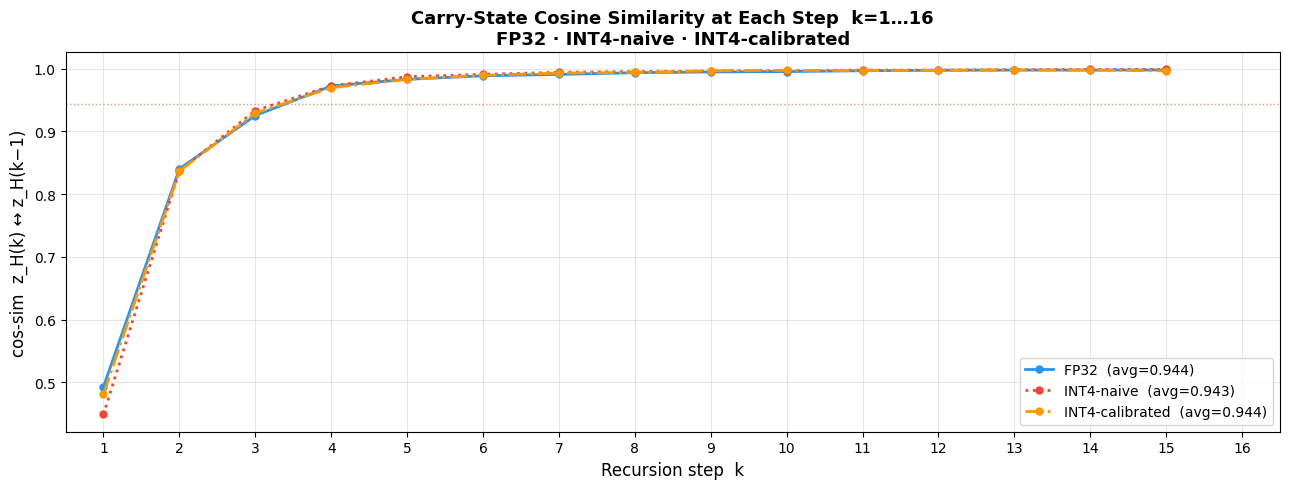

Saved: carry_sim_profile_k16.png

────────────────────────────────────────────────────────────────────────────
   k              FP32              INT8        INT4-naive   INT4-calibrated
────────────────────────────────────────────────────────────────────────────
   1  0.4929                 —  0.4487  0.4812
   2  0.8401                 —  0.8371  0.8366
   3  0.9251                 —  0.9330  0.9288
   4  0.9721                 —  0.9723  0.9696
   5  0.9828                 —  0.9870  0.9827
   6  0.9885                 —  0.9908  0.9892
   7  0.9906                 —  0.9940  0.9927
   8  0.9934                 —  0.9952  0.9938
   9  0.9945                 —  0.9961  0.9963
  10  0.9952                 —  0.9967  0.9971
  11  0.9965                 —  0.9975  0.9967
  12  0.9973                 —  0.9975  0.9971
  13  0.9975                 —  0.9982  0.9977
  14  0.9976                 —  0.9985  0.9974
  15  0.9978                 —  0.9986  0.9963
──────────────────────────────

In [13]:
N_SIM_STEPS   = 16
N_SIM_BATCHES = 5

sim_profiles = {}
for vname, (vm, dev) in variants.items():
    print(f'Collecting — {vname} on {dev}…')
    try:
        profile = collect_carry_sim_profile(vm, train_loader, dev,
                                            n_steps=N_SIM_STEPS,
                                            n_batches=N_SIM_BATCHES)
        sim_profiles[vname] = profile
        avg = np.mean(profile) if profile else float('nan')
        print(f'  {len(profile)} steps | avg={avg:.4f}')
        print('  [' + ', '.join(f'{v:.3f}' for v in profile) + ']')
    except Exception as e:
        import traceback; traceback.print_exc()
        sim_profiles[vname] = []

# ── Figure ─────────────────────────────────────────────────────────────────
PALETTE = {'FP32':'#2196F3','INT8':'#4CAF50','INT4-calibrated':'#FF9800','INT4-naive':'#F44336'}
LS_MAP  = {'FP32':'-','INT8':'--','INT4-calibrated':'-.','INT4-naive':':'}

fig, ax = plt.subplots(figsize=(13, 5))
for vname, profile in sim_profiles.items():
    if not profile: continue
    avg = np.mean(profile)
    ax.plot(range(1, len(profile)+1), profile,
            marker='o', ms=5, lw=2,
            color=PALETTE.get(vname,'gray'), ls=LS_MAP.get(vname,'-'),
            label=f'{vname}  (avg={avg:.3f})')
    ax.axhline(avg, color=PALETTE.get(vname,'gray'), ls=':', alpha=0.3, lw=1)
ax.set_xlim(0.5, N_SIM_STEPS+0.5)
ax.set_xticks(range(1, N_SIM_STEPS+1))
ax.set_xlabel('Recursion step  k', fontsize=12)
ax.set_ylabel('cos-sim  z_H(k) ↔ z_H(k−1)', fontsize=12)
# Title reflects only the variants that actually ran
present = ' · '.join(k for k, p in sim_profiles.items() if p)
ax.set_title(f'Carry-State Cosine Similarity at Each Step  k=1…16\n{present}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('carry_sim_profile_k16.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: carry_sim_profile_k16.png')

# ── Table ──────────────────────────────────────────────────────────────────
col_w  = 16
header = f"{'k':>4}" + ''.join(f'  {n:>{col_w}}' for n in sim_profiles)
sep    = chr(0x2500) * len(header)
print(f'\n{sep}\n{header}\n{sep}')
max_k  = max((len(v) for v in sim_profiles.values() if v), default=0)
for k in range(max_k):
    row = f'{k+1:>4}'
    for p in sim_profiles.values():
        row += f'  {p[k]:.4f}' if k < len(p) else f'  {chr(0x2014):>{col_w}}'
    print(row)
print(sep)
avg_r = f"{'avg':>4}"
for p in sim_profiles.values():
    avg_r += f'  {np.mean(p):.4f}' if p else f'  {chr(0x2014):>{col_w}}'
print(avg_r + '\n' + sep)

## Exp-2 · Accuracy vs. Depth  (k = 1, 2, 4, 8, 16)
Temporarily patches `inner.config.H_cycles` via `evaluate_at_depth()`.
Each depth×precision combination runs `max_batches=15` batches (~480 puzzles).


Precision                k    Cell Acc
----------------------------------------
FP32                     1      0.5990
FP32                     2      0.6919
FP32                     4      0.7201
FP32                     8      0.7165
FP32                    16      0.6988

cuBLAS API failed with status 15
error detected  [WARN] INT8 k=1: cublasLt ran into an error!
	shapeA=torch.Size([2, 512]), shapeB=torch.Size([32, 512]), shapeC=(32, 2)
	(lda, ldb, ldc)=(c_int(512), c_int(512), c_int(2))
	(m, n, k)=(c_int(512), c_int(32), c_int(2))
INT8                     1         nan
cuBLAS API failed with status 15
error detected  [WARN] INT8 k=2: cublasLt ran into an error!
	shapeA=torch.Size([2, 512]), shapeB=torch.Size([32, 512]), shapeC=(32, 2)
	(lda, ldb, ldc)=(c_int(512), c_int(512), c_int(2))
	(m, n, k)=(c_int(512), c_int(32), c_int(2))
INT8                     2         nan
cuBLAS API failed with status 15
error detected  [WARN] INT8 k=4: cublasLt ran into an error!
	shapeA=torch.Size([

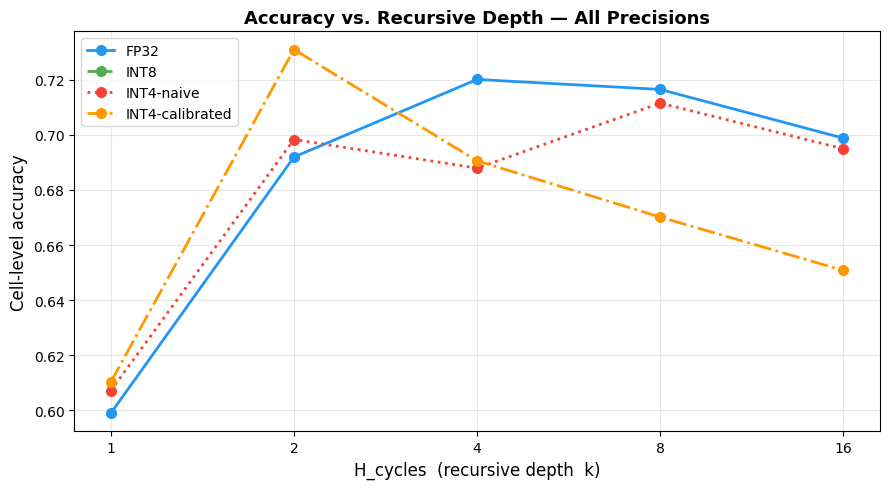

Saved: accuracy_vs_depth_k16.png


In [14]:
H_DEPTHS    = [1, 2, 4, 8, 16]
MAX_BATCHES = 15

depth_results = {}
print(f"{'Precision':<20}  {'k':>4}  {'Cell Acc':>10}")
print('-' * 40)

for vname, (vm, dev) in variants.items():
    for h in H_DEPTHS:
        try:
            _, cell = evaluate_at_depth(vm, train_loader, h,
                                        device=dev, max_batches=MAX_BATCHES)
        except Exception as e:
            print(f'  [WARN] {vname} k={h}: {e}')
            cell = float('nan')
        depth_results[(vname, h)] = cell
        print(f'{vname:<20}  {h:>4}  {cell:>10.4f}')
    print()

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for vname in variants:
    ys = [depth_results.get((vname, h), float('nan')) for h in H_DEPTHS]
    ax.plot(H_DEPTHS, ys, marker='o', ms=7, lw=2,
            color=PALETTE.get(vname,'gray'), ls=LS_MAP.get(vname,'-'), label=vname)
ax.set_xscale('log', base=2)
ax.set_xticks(H_DEPTHS); ax.set_xticklabels([str(h) for h in H_DEPTHS])
ax.set_xlabel('H_cycles  (recursive depth  k)', fontsize=12)
ax.set_ylabel('Cell-level accuracy', fontsize=12)
ax.set_title('Accuracy vs. Recursive Depth \u2014 All Precisions',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_depth_k16.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_vs_depth_k16.png')
